# PHYS 332 - Numerical Techniques for the Sciences II
## Homework 03: PDEs -- Diffusive Initial Value Problems
### Problem 4 -  Implementation and Tests
---
Name: *Ethan Duarte*

Cells for *Problem 4* are below.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import solve_banded
from scipy.sparse import diags
from scipy.sparse.linalg import splu

### Partial differential equations: Diffusion problem.

Here we'll integrate the diffusion (or heat) equation with constant conductivity $\kappa$,

$$\frac{\partial T}{\partial t} = \kappa \frac{\partial^2}{\partial x^2} T(x,t),$$

using the three schemes from the assignment sheet: forward-time centered-space (FTCS), fully implicit, and Crank-Nicholson.  As in `FTCS_Example.ipynb` from class, almost everything you need is here, but you'll have to insert code into the three integrators and into the analytic solution to get it working.  Otherwise we have the following functions:

- `diffusion_solve`    - Driver for the actual integrators: generates the support point arrays in space and time, and calls the integrator
- `ftcs`, `implicit`, `cranknicholson` - The three integrators (**your code goes here**)
- `init`               - Picks the initial conditions, the boundary conditions, and the domain for a given problem (the integrator is chosen with the `integrator` keyword of `diffusion_solve`)
- `Tconst`, `Tspike`, `Trandom` - Functions for setting the initial conditions
- `diffusion_analytic` - The analytic solution for the constant-temperature rod (**your code goes here**)

The spatial grid is the same as in class (and in Numerical Recipes, Ch. 20): the temperature values $T_j$ live at the $J+1$ support points $x_j = x_{min} + j\Delta x$, $j = 0\dots J$, with $\Delta x = (x_{max}-x_{min})/J$, so that the two domain walls are the support points $j=0$ and $j=J$.  As in class, the solution array is stored with time along the first axis: row $n$ is the spatial slice at time $t_n$.  What is new is that two of the three schemes are implicit: instead of a matrix-vector multiplication, the update requires solving a linear system at every timestep.  You will use SciPy's solvers for that (see the SciPy imports above, and look at their documentation!).

## Driver for the actual integrators

Generates the support point arrays in space and time and calls the integrator selected with the `integrator` keyword.  This is provided for you.  Note that it prints out the value of $\alpha\equiv\kappa\Delta t/(\Delta x)^2$ and the number of time support points $N$ (i.e. $N-1$ timesteps) -- you will need both for the tests.  Note also that the timestep is recalculated slightly, so that an integer number of steps lands exactly on the final time (compare to `pde_stepper` from class, where $N$ counts the steps and $\Delta t$ is kept fixed).

In [2]:
def diffusion_solve(J,minmax_x,delta_t,minmax_t,init_cond,**kwargs):
    """
    Driver for the actual integrators. Generates the support point
    arrays in space and time, and calls the integrator.

    PARAMETERS:
    input:
        J              -- number of spatial intervals (J+1 points, including the two walls)
        minmax_x       -- 2-element array containing minimum and maximum of spatial domain
        delta_t        -- requested timestep (recalculated slightly so that N-1 steps land exactly on minmax_t[1])
        minmax_t       -- 2-element array, same for time domain
        init_cond      -- initial condition function
        kappa          -- (keyword argument) conductivity, default 1.0
        integrator     -- (keyword argument) either "ftcs" (default), "implicit", or "cranknicholson"
        boundary_cond  -- (keyword argument) boundary condition flag, "dirichlet" (default) or "periodic";
                          passed on to the integrator

    RETURNS:
        x : positions of the J+1 spatial support points; x[0] = xmin and x[J] = xmax are the walls
        t : the N temporal support points
        T : (N,J+1) solution array; row n is the spatial slice at time t[n]
    """
    kappa      = kwargs.get('kappa',1.0)
    integrator = kwargs.get('integrator',"ftcs")

    if integrator == "ftcs":
        integrator_func = ftcs
    elif integrator == "implicit":
        integrator_func = implicit
    elif integrator == "cranknicholson":
        integrator_func = cranknicholson
    else:
        raise ValueError('[diffusion_solve]: '+str(integrator)+' is not a valid integrator')

    # time and space discretization
    N       = int(round((minmax_t[1]-minmax_t[0])/delta_t))+1   # time support points, including t=0
    delta_t = (minmax_t[1]-minmax_t[0])/float(N-1)              # recalculate, to make exact
    delta_x = (minmax_x[1]-minmax_x[0])/float(J)
    x       = minmax_x[0]+np.arange(J+1)*delta_x                # support points x_j = xmin + j*delta_x, j = 0 ... J
    t       = minmax_t[0]+np.arange(N)*delta_t
    # alpha factor
    alpha   = kappa*delta_t/delta_x**2
    print('[diffusion_solve]: alpha = %13.5e' % (alpha))
    print('[diffusion_solve]: N     = %7i time support points, i.e. %i timesteps' % (N,N-1))
    T       = integrator_func(x,t,alpha,init_cond,**kwargs)
    return x,t,T

## The three integrators


### Forward-time centered-space integrator

In [3]:
def ftcs(x,t,alpha,init_cond,**kwargs):
    """
    Forward-time centered-space integrator.
    Returns the full solution array (including
    initial conditions at t=0). Array should be
    of shape (N,J+1), with N the number of temporal
    and J+1 the number of spatial support points.

    PARAMETERS:
    input:
        x             -- positions of the J+1 spatial support points (x[0] and x[J] are the walls)
        t             -- the N temporal support points
        alpha         -- kappa*delta_t/delta_x**2
        init_cond     -- initial condition function
        boundary_cond -- (keyword argument) "dirichlet" (default): the walls T[n,0] and T[n,J] are held at 0
                         for all n, including n=0; "periodic": x[0] and x[J] are the same physical point,
                         the unknowns are j = 0 ... J-1 and T[n,J] is a copy of T[n,0]

    RETURNS:
        T : (N,J+1) solution array; row n is the spatial slice at time t[n]
    """
    boundary_cond = kwargs.get('boundary_cond',"dirichlet")
    J = x.size-1
    N = t.size
    T = np.zeros((N,J+1))
    T[0,:] = init_cond(x)

    if boundary_cond == "dirichlet":
        T[0,0] = 0.0
        T[0,J] = 0.0

        for n in range(N-1):
            T[n+1,1:J] = T[n,1:J] + alpha*(
                T[n,2:J+1] - 2.0*T[n,1:J] + T[n,0:J-1]
            )

    elif boundary_cond == "periodic":
        T[0,J] = T[0,0]

        for n in range(N-1):
            T[n+1,:J] = T[n,:J] + alpha*(
                np.roll(T[n,:J],-1)
                - 2.0*T[n,:J]
                + np.roll(T[n,:J],1)
            )
            T[n+1,J] = T[n+1,0]

    return T

### Fully implicit integrator

In [4]:
def implicit(x,t,alpha,init_cond,**kwargs):
    """
    Fully implicit integrator.
    Returns the full solution array (including
    initial conditions at t=0). Array should be
    of shape (N,J+1), with N the number of temporal
    and J+1 the number of spatial support points.
    Uses solve_banded ("dirichlet") or splu ("periodic")
    to solve the linear system at every timestep.

    PARAMETERS:
    input:
        x             -- positions of the J+1 spatial support points (x[0] and x[J] are the walls)
        t             -- the N temporal support points
        alpha         -- kappa*delta_t/delta_x**2
        init_cond     -- initial condition function
        boundary_cond -- (keyword argument) "dirichlet" (default): the walls T[n,0] and T[n,J] are held at 0
                         for all n, including n=0; "periodic": x[0] and x[J] are the same physical point,
                         the unknowns are j = 0 ... J-1 and T[n,J] is a copy of T[n,0]

    RETURNS:
        T : (N,J+1) solution array; row n is the spatial slice at time t[n]
    """
    boundary_cond = kwargs.get('boundary_cond',"dirichlet")
    J = x.size-1
    N = t.size
    T = np.zeros((N,J+1))
    T[0,:] = init_cond(x)

    if boundary_cond == "dirichlet":
        T[0,0] = 0.0
        T[0,J] = 0.0

        ab = np.zeros((3,J-1))
        ab[0,1:]  = -alpha
        ab[1,:]   = 1.0 + 2.0*alpha
        ab[2,:-1] = -alpha

        for n in range(N-1):
            T[n+1,1:J] = solve_banded((1,1),ab,T[n,1:J])

    elif boundary_cond == "periodic":
        T[0,J] = T[0,0]

        A = diags(
            [-alpha*np.ones(J-1),
             (1.0+2.0*alpha)*np.ones(J),
             -alpha*np.ones(J-1)],
            [-1,0,1],
            format='lil'
        )

        A[0,J-1] = -alpha
        A[J-1,0] = -alpha
        lu = splu(A.tocsc())

        for n in range(N-1):
            T[n+1,:J] = lu.solve(T[n,:J])
            T[n+1,J] = T[n+1,0]

    return T

### Crank-Nicholson integrator

In [5]:
def cranknicholson(x,t,alpha,init_cond,**kwargs):
    """
    Crank-Nicholson integrator.
    Returns the full solution array (including
    initial conditions at t=0). Array should be
    of shape (N,J+1), with N the number of temporal
    and J+1 the number of spatial support points.
    Uses solve_banded ("dirichlet") or splu ("periodic")
    to solve the linear system at every timestep.

    PARAMETERS:
    input:
        x             -- positions of the J+1 spatial support points (x[0] and x[J] are the walls)
        t             -- the N temporal support points
        alpha         -- kappa*delta_t/delta_x**2
        init_cond     -- initial condition function
        boundary_cond -- (keyword argument) "dirichlet" (default): the walls T[n,0] and T[n,J] are held at 0
                         for all n, including n=0; "periodic": x[0] and x[J] are the same physical point,
                         the unknowns are j = 0 ... J-1 and T[n,J] is a copy of T[n,0]

    RETURNS:
        T : (N,J+1) solution array; row n is the spatial slice at time t[n]
    """
    boundary_cond = kwargs.get('boundary_cond',"dirichlet")
    J = x.size-1
    N = t.size
    T = np.zeros((N,J+1))
    T[0,:] = init_cond(x)

    if boundary_cond == "dirichlet":
        T[0,0] = 0.0
        T[0,J] = 0.0

        ab = np.zeros((3,J-1))
        ab[0,1:]  = -0.5*alpha
        ab[1,:]   = 1.0 + alpha
        ab[2,:-1] = -0.5*alpha

        for n in range(N-1):
            rhs = (
                (1.0-alpha)*T[n,1:J]
                + 0.5*alpha*(T[n,0:J-1] + T[n,2:J+1])
            )

            T[n+1,1:J] = solve_banded((1,1),ab,rhs)

    elif boundary_cond == "periodic":
        T[0,J] = T[0,0]

        A = diags(
            [-0.5*alpha*np.ones(J-1),
             (1.0+alpha)*np.ones(J),
             -0.5*alpha*np.ones(J-1)],
            [-1,0,1],
            format='lil'
        )

        A[0,J-1] = -0.5*alpha
        A[J-1,0] = -0.5*alpha
        lu = splu(A.tocsc())

        for n in range(N-1):
            old = T[n,:J]

            rhs = (
                (1.0-alpha)*old
                + 0.5*alpha*(
                    np.roll(old,-1)
                    + np.roll(old,1)
                )
            )

            T[n+1,:J] = lu.solve(rhs)
            T[n+1,J] = T[n+1,0]

    return T

## Setting up the problem

`init` returns the initial condition function `init_cond`, the boundary condition flag `boundary_cond`, and the spatial and temporal domains `minmax_x` and `minmax_t`, for a given choice of

```
problem : initial conditions:
    const   : constant temperature (Dirichlet walls, T=0)
    spike   : peaked gaussian      (Dirichlet walls, T=0)
    random  : random noise         (periodic)
```

The integrator itself is chosen when calling `diffusion_solve`, with `integrator` set to `'ftcs'`, `'implicit'`, or `'cranknicholson'`.  This is provided for you.

In [6]:
def init(problem):
    """
    Picks the initial and boundary conditions and the domain for a given problem.

    PARAMETERS:
    input:
        problem -- 'const', 'spike', or 'random'

    RETURNS:
        init_cond     : initial condition function
        boundary_cond : boundary condition flag ('dirichlet' or 'periodic')
        minmax_x      : 2-element array containing minimum and maximum of spatial domain
        minmax_t      : 2-element array, same for time domain
    """
    if (problem == 'const'):
        init_cond     = Tconst
        boundary_cond = 'dirichlet'
        minmax_x      = np.array([-0.5,0.5])
        minmax_t      = np.array([0.0,1.0])
    elif (problem == 'spike'):
        init_cond     = Tspike
        boundary_cond = 'dirichlet'
        minmax_x      = np.array([-0.5,0.5])
        minmax_t      = np.array([0.0,1.0])
    elif (problem == 'random'):
        init_cond     = Trandom
        boundary_cond = 'periodic'
        minmax_x      = np.array([-0.5,0.5])
        minmax_t      = np.array([0.0,1.0])
    else:
        raise ValueError('[init]: invalid problem %s' % (problem))

    return init_cond,boundary_cond,minmax_x,minmax_t

## Functions for setting the initial conditions (T....)

In [7]:
def Tconst(x):
    return np.zeros(x.size)+1.0

def Tspike(x):
    return np.exp(-10.0*x**2)

def Trandom(x):
    return np.random.rand(x.size)+1.0

## The analytic solution

In [8]:
def diffusion_analytic(x,t):
    """
    Returns a (N,J+1) array with the analytic solution
    to the diffusion problem (see Hancock 2006).

    PARAMETERS:
    input:
        x -- positions of the J+1 spatial support points (x[0] and x[J] are the walls)
        t -- the N temporal support points

    RETURNS:
        T_analy : (N,J+1) array with the analytic solution; row n is the
                  spatial slice at time t[n]
    """
    xmin    = x[0]
    xmax    = x[x.size-1]
    J       = x.size-1
    N       = t.size
    T_analy = np.zeros((N,J+1))
    L = xmax-xmin

    for m in range(1,200,2):
        T_analy += (4.0/(m*np.pi))*np.outer(
            np.exp(-(m*np.pi/L)**2*t),
            np.sin(m*np.pi*(x-xmin)/L)
        )

    if np.isclose(t[0],0.0):
        T_analy[0,1:J] = 1.0
        T_analy[0,0] = 0.0
        T_analy[0,J] = 0.0

    return T_analy

## The main program


In [9]:
J          = 20          # number of spatial intervals (J+1 support points, including the two walls)
delta_t    = 1.25e-3      # timestep -- you need to calculate the appropriate value for the tests!
integrator = 'ftcs'      # 'ftcs', 'implicit', or 'cranknicholson'
problem    = 'const'     # 'const', 'spike', or 'random'

init_cond,boundary_cond,minmax_x,minmax_t = init(problem)
x,t,T = diffusion_solve(J,minmax_x,delta_t,minmax_t,init_cond,integrator=integrator,boundary_cond=boundary_cond)

for integrator in ['ftcs','implicit','cranknicholson']:
    print('\n',integrator)

    x,t,T = diffusion_solve(
        J,minmax_x,delta_t,minmax_t,init_cond,
        integrator=integrator,
        boundary_cond=boundary_cond
    )

    Tana = diffusion_analytic(x,t)
    rmsdiff = np.sqrt(np.mean((T-Tana)**2,axis=1))

    print('mean rms difference = %13.5e' % np.mean(rmsdiff))

[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps

 ftcs
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   1.03388e-03

 implicit
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   8.45687e-04

 cranknicholson
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   1.57402e-04


## Plots



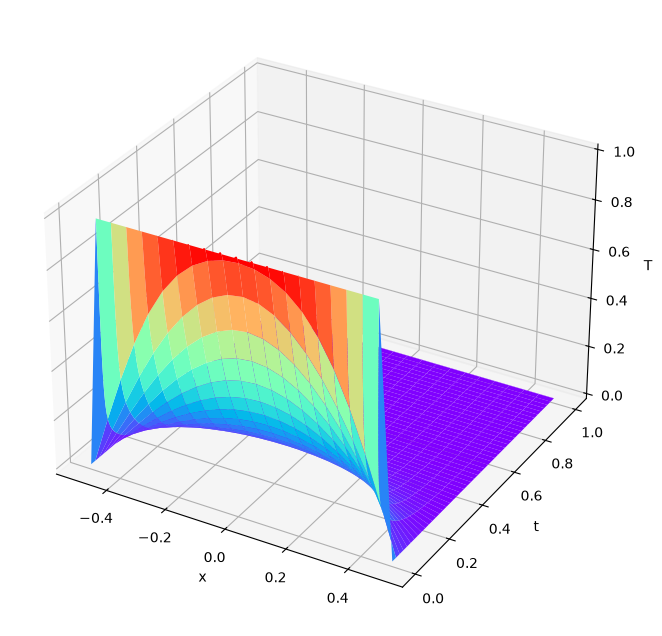

[plots]: rms difference to the analytic solution, averaged over the run:   1.57402e-04


C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\558670806.py:29: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t,np.log10(np.abs(maxT-maxTana)),linestyle='-',linewidth=1,color='black')
C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\558670806.py:35: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t,np.log10(rmsdiff),linestyle='-',linewidth=1,color='black')


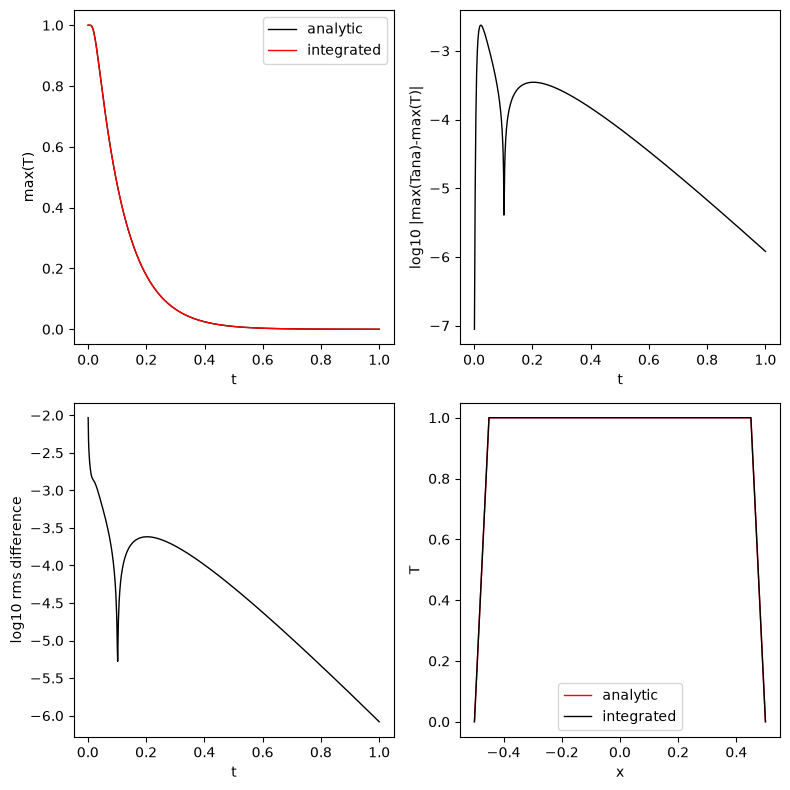

In [10]:
ftsz    = 10
fig     = plt.figure(num=1,figsize=(8,8),dpi=100,facecolor='white')
ax      = fig.add_subplot(111,projection='3d')
x2d,t2d = np.meshgrid(x,t)
ax.plot_surface(x2d,t2d,T,cmap='rainbow')
ax.set_zlabel('T')
ax.set_ylabel('t')
ax.set_xlabel('x')
ax.tick_params(labelsize=ftsz)
plt.show()

if (problem=='const'):
    Tana    = diffusion_analytic(x,t)
    rmsdiff = np.sqrt(np.mean((T-Tana)**2,axis=1))
    maxTana = np.max(Tana,axis=1)
    maxT    = np.max(T,axis=1)
    print('[plots]: rms difference to the analytic solution, averaged over the run: %13.5e' % (np.mean(rmsdiff)))

    plt.figure(num=2,figsize=(8,8),dpi=100,facecolor='white')
    plt.subplot(221)
    plt.plot(t,maxTana,linestyle='-',linewidth=1,color='black',label='analytic')
    plt.plot(t,maxT,linestyle='-',linewidth=1,color='red',label='integrated')
    plt.xlabel('t')
    plt.ylabel('max(T)')
    plt.legend(fontsize=ftsz)
    plt.tick_params(labelsize=ftsz)

    plt.subplot(222)
    plt.plot(t,np.log10(np.abs(maxT-maxTana)),linestyle='-',linewidth=1,color='black')
    plt.xlabel('t')
    plt.ylabel('log10 |max(Tana)-max(T)|')
    plt.tick_params(labelsize=ftsz)

    plt.subplot(223)
    plt.plot(t,np.log10(rmsdiff),linestyle='-',linewidth=1,color='black')
    plt.xlabel('t')
    plt.ylabel('log10 rms difference')
    plt.tick_params(labelsize=ftsz)

    plt.subplot(224)
    plt.plot(x,Tana[0,:],linestyle='-',linewidth=1,color='red',label='analytic')
    plt.plot(x,T[0,:],linestyle='-',linewidth=1,color='black',label='integrated')
    plt.xlabel('x')
    plt.ylabel('T')
    plt.legend(fontsize=ftsz)
    plt.tick_params(labelsize=ftsz)

    plt.tight_layout()
    plt.show()

## Tests

Use the cells below for the runs in part (d) (you can copy the main program and the plotting cells from above, or wrap them in a function), and write your answers to the questions in the markdown cell at the end.

In [11]:
## (d) J = 20: ftcs, implicit, and cranknicholson
J = 20
delta_t = 1.25e-3
problem = 'const'

init_cond,boundary_cond,minmax_x,minmax_t = init(problem)

for integrator in ['ftcs','implicit','cranknicholson']:
    print('\n',integrator)

    x,t,T = diffusion_solve(
        J,minmax_x,delta_t,minmax_t,init_cond,
        integrator=integrator,
        boundary_cond=boundary_cond
    )

    Tana = diffusion_analytic(x,t)
    rmsdiff = np.sqrt(np.mean((T-Tana)**2,axis=1))

    print('mean rms difference = %13.5e' % np.mean(rmsdiff))


 ftcs
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   1.03388e-03

 implicit
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   8.45687e-04

 cranknicholson
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   1.57402e-04


In [12]:
## (d) J = 40, keeping the same delta_t: ftcs, implicit, and cranknicholson
J = 40
delta_t = 1.25e-3
problem = 'const'

init_cond,boundary_cond,minmax_x,minmax_t = init(problem)

for integrator in ['ftcs','implicit','cranknicholson']:
    print('\n',integrator)

    x,t,T = diffusion_solve(
        J,minmax_x,delta_t,minmax_t,init_cond,
        integrator=integrator,
        boundary_cond=boundary_cond
    )

    Tana = diffusion_analytic(x,t)
    rmsdiff = np.sqrt(np.mean((T-Tana)**2,axis=1))

    print('mean rms difference = %13.5e' % np.mean(rmsdiff))


 ftcs
[diffusion_solve]: alpha =   2.00000e+00
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =           nan

 implicit
[diffusion_solve]: alpha =   2.00000e+00
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   8.20621e-04

 cranknicholson
[diffusion_solve]: alpha =   2.00000e+00
[diffusion_solve]: N     =     801 time support points, i.e. 800 timesteps
mean rms difference =   1.04696e-04


C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\3329631488.py:34: RuntimeWarning: overflow encountered in multiply
  T[n,2:J+1] - 2.0*T[n,1:J] + T[n,0:J-1]
C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\3329631488.py:34: RuntimeWarning: overflow encountered in subtract
  T[n,2:J+1] - 2.0*T[n,1:J] + T[n,0:J-1]
C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\3329631488.py:34: RuntimeWarning: overflow encountered in add
  T[n,2:J+1] - 2.0*T[n,1:J] + T[n,0:J-1]
C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\3329631488.py:33: RuntimeWarning: overflow encountered in multiply
  T[n+1,1:J] = T[n,1:J] + alpha*(
C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\3329631488.py:33: RuntimeWarning: invalid value encountered in add
  T[n+1,1:J] = T[n,1:J] + alpha*(
C:\Users\dshin\AppData\Local\Temp\ipykernel_21908\4167442074.py:18: RuntimeWarning: overflow encountered in square
  rmsdiff = np.sqrt(np.mean((T-Tana)**2,axis=1))
C:\Users\dshin\anaconda3\Lib\site-packages\numpy\_core\_methods.p

In [13]:
## (d) J = 40: the stable delta_t for ftcs
J = 40
delta_t = 3.125e-4
problem = 'const'

init_cond,boundary_cond,minmax_x,minmax_t = init(problem)

for integrator in ['ftcs','implicit','cranknicholson']:
    print('\n',integrator)

    x,t,T = diffusion_solve(
        J,minmax_x,delta_t,minmax_t,init_cond,
        integrator=integrator,
        boundary_cond=boundary_cond
    )

    Tana = diffusion_analytic(x,t)
    rmsdiff = np.sqrt(np.mean((T-Tana)**2,axis=1))

    print('mean rms difference = %13.5e' % np.mean(rmsdiff))


 ftcs
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =    3201 time support points, i.e. 3200 timesteps
mean rms difference =   2.80008e-04

 implicit
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =    3201 time support points, i.e. 3200 timesteps
mean rms difference =   2.31713e-04

 cranknicholson
[diffusion_solve]: alpha =   5.00000e-01
[diffusion_solve]: N     =    3201 time support points, i.e. 3200 timesteps
mean rms difference =   4.30775e-05


*Your answers to the questions in part (d) go here.*